In [1]:
from tensorflow.keras import Sequential

from tensorflow.keras.layers import Input, Dense, Dropout, Flatten

from tensorflow.keras.layers import Conv2D, MaxPooling2D

I0000 00:00:1780971276.047265   38551 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780971276.087600   38551 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780971277.083657   38551 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## CNN in MNIST Data

In [2]:
# from tensorflow.keras.datasets import mnist 
from tensorflow.keras.datasets import cifar10 

In [3]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

/home/shailesh/Desktop/education/DSML-10/.venv/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


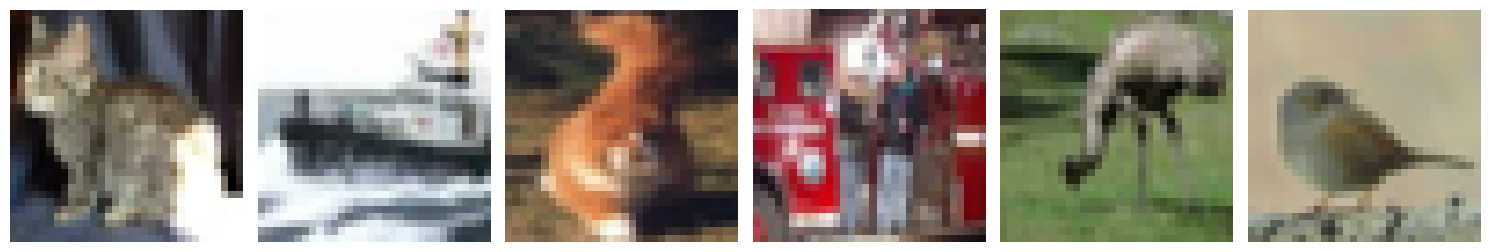

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Select 6 images (you can choose specific indices if needed)
indices = np.random.choice(len(X_train), 6, replace=False)
selected_images = [X_train[i] for i in indices]

# Create subplots
fig, axes = plt.subplots(1, 6, figsize=(15, 5))

# Plot each image
for ax, img in zip(axes, selected_images):
    ax.imshow(img, cmap='gray')  # Display image in grayscale
    ax.axis('off')  # Turn off axes for a cleaner look

# Display the plot
plt.tight_layout()
plt.show()

In [5]:
# Data Preprocessing

# X_train = X_train.reshape(*X_train.shape, 1)
# X_test = X_test.reshape(*X_test.shape, 1)

# min-max scaling
X_train = X_train / 255
X_test = X_test / 255

In [6]:
from sklearn.preprocessing import OneHotEncoder

onehot_encoder = OneHotEncoder(sparse_output=False)

enc_y_train = onehot_encoder.fit_transform(y_train.reshape(-1,1))

## Model Defination

In [7]:
input_shape = X_train.shape[1:]
input_shape

(32, 32, 3)

In [13]:
model = Sequential()

model.add(Input(shape=input_shape))

# Convo Layer 1
model.add(Conv2D(filters = 32, kernel_size=(3,3), strides=(1,1), padding="same", activation="relu" ))
model.add(MaxPooling2D(pool_size=(2,2), strides=2))

# Convo Layer 2
model.add(Conv2D(filters = 16, kernel_size=(3,3), strides=(1,1), padding="valid", activation="relu" ))
model.add(MaxPooling2D(pool_size=(2,2), strides=2))

model.add(Flatten())

# Fully Conneced Layer
model.add(Dense(120, activation="relu"))
model.add(Dropout(0.2)) # 25% weight dropout
model.add(Dense(60, activation="relu"))
# Output
model.add(Dense(10, activation="softmax"))


model.compile(
    optimizer = "adam",
    loss = "categorical_crossentropy",
    metrics=["accuracy"]
)


In [14]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 120)            │        94,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 60)             │         7,260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           610 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,590 (420.27 KB)

 Trainable params: 107,590 (420.27 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(
    X_train, 
    enc_y_train, 
    epochs=25, 
    batch_size=32,
    shuffle=True, 
    validation_split = 0.2
)

Epoch 1/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4286 - loss: 1.5691 - val_accuracy: 0.5245 - val_loss: 1.3159
Epoch 2/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5491 - loss: 1.2613 - val_accuracy: 0.5857 - val_loss: 1.1815
Epoch 3/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5929 - loss: 1.1461 - val_accuracy: 0.6176 - val_loss: 1.0844
Epoch 4/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6235 - loss: 1.0628 - val_accuracy: 0.6300 - val_loss: 1.0527
Epoch 5/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6496 - loss: 0.9948 - val_accuracy: 0.6343 - val_loss: 1.0355
Epoch 6/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6672 - loss: 0.9403 - val_accuracy: 0.6412 - val_loss: 1.0314
Epoch 7/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6820 - loss: 0.8991 - val_accuracy: 0.6590 - val_loss: 0.9799
Epoch 8/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6925 - loss: 0.8637 - 

<Axes: >

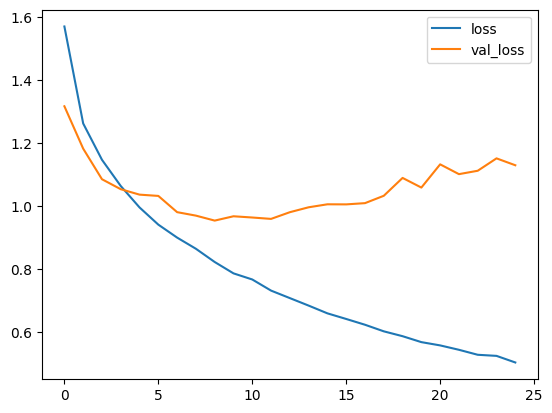

In [16]:
import pandas as pd
df = pd.DataFrame(history.history)

df[["loss","val_loss"]].plot.line()

In [12]:
from sklearn.metrics import confusion_matrix

pred = np.argmax(model.predict(X_test), axis=1)

confusion_matrix(y_test, pred)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[580,  29,  68,   9,  26,   3,  22,  11, 190,  62],
       [ 27, 693,   7,   5,   5,   6,  23,   1,  94, 139],
       [ 58,  12, 539,  44, 124,  47,  90,  13,  50,  23],
       [ 21,  20, 144, 310, 111, 113, 167,  21,  44,  49],
       [ 23,   5, 136,  40, 559,  32, 119,  47,  28,  11],
       [ 15,   8, 140, 151,  91, 394,  91,  40,  34,  36],
       [  9,   8,  58,  29,  51,   9, 798,   2,  16,  20],
       [ 19,  10,  76,  44, 125,  60,  27, 582,  11,  46],
       [ 50,  37,  17,  10,  10,   3,   9,   2, 829,  33],
       [ 42,  94,  12,  11,  10,   5,  20,   8,  77, 721]])